In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [17]:
# --- 1. SETTINGS ---
os.environ["LOKY_MAX_CPU_COUNT"] = "4" 
plt.rcParams.update({'text.usetex': False})
tf.random.set_seed(42)
WINDOW_SIZE = 50
HEALTHY_RUL_THRESHOLD = 125 # Cycles before failure where degradation typically begins

In [18]:
# --- 2. DOWNLOAD & LOAD ---
path = kagglehub.dataset_download("palbha/cmapss-jet-engine-simulated-data")
print("Path to dataset files:", path)

# UPDATED TO FD004
columns = ['id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f's_{i}' for i in range(1, 22)]
df = pd.read_csv(f"{path}/train_FD004.txt", sep='\s+', header=None, names=columns)
df_test = pd.read_csv(f"{path}/test_FD004.txt", sep='\s+', header=None, names=columns)

Path to dataset files: C:\Users\Nishanth Kunchala\.cache\kagglehub\datasets\palbha\cmapss-jet-engine-simulated-data\versions\1


In [19]:
# --- 3. CALCULATE RUL FOR TRAINING DATA ---
# Since engines in the train set run to failure, RUL is (Max Cycle - Current Cycle)
max_cycles = df.groupby('id')['cycle'].max().reset_index()
max_cycles.columns = ['id', 'max_cycle']
df = df.merge(max_cycles, on=['id'], how='left')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

In [20]:
# --- 4. CLEANING ---
drop_cols = ['s_13', 's_16', 's_19']
df.drop(labels=drop_cols, axis=1, inplace=True)
df_test.drop(labels=drop_cols, axis=1, inplace=True)

setting_cols = ['setting1', 'setting2', 'setting3']
sensor_cols = [c for c in df.columns if c.startswith('s_')]

In [21]:
# --- 5. REGIME-BASED SCALING (The K-Means Fix) ---
print("Clustering operating conditions...")
# 1. Find the 6 flight conditions based on the settings
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[setting_cols])
df_test['cluster'] = kmeans.predict(df_test[setting_cols])

# 2. Normalize the sensors WITHIN each specific cluster
healthy_mask = df['RUL'] > HEALTHY_RUL_THRESHOLD

for cluster_id in range(6):
    train_cluster_mask = df['cluster'] == cluster_id
    test_cluster_mask = df_test['cluster'] == cluster_id
    
    # Fit scaler ONLY on the healthy data of THIS specific flight condition
    scaler = StandardScaler()
    healthy_cluster_data = df[train_cluster_mask & healthy_mask][sensor_cols]
    
    # Fallback in case a specific condition has no healthy data
    if len(healthy_cluster_data) == 0:
        scaler.fit(df[train_cluster_mask][sensor_cols])
    else:
        scaler.fit(healthy_cluster_data)
    
    # Transform the data
    df.loc[train_cluster_mask, sensor_cols] = scaler.transform(df.loc[train_cluster_mask, sensor_cols])
    df_test.loc[test_cluster_mask, sensor_cols] = scaler.transform(df_test.loc[test_cluster_mask, sensor_cols])

# Now that the conditions are normalized out, our features are just the smooth sensors!
feature_cols = sensor_cols

Clustering operating conditions...


In [22]:
# --- 6. SEQUENCING FUNCTION ---
def gen_sequences_and_labels(data, window):
    sequences, cycles, ruls = [], [], []
    for unit_id in data['id'].unique():
        unit_data = data[data['id'] == unit_id]
        
        # Using the perfectly flattened sensor_cols now
        feature_vals = unit_data[feature_cols].values
        cycle_vals = unit_data['cycle'].values
        rul_vals = unit_data['RUL'].values if 'RUL' in unit_data.columns else np.zeros(len(unit_data))
        
        if len(unit_data) >= window:
            for i in range(len(unit_data) - window):
                sequences.append(feature_vals[i:i+window])
                cycles.append(cycle_vals[i+window])
                ruls.append(rul_vals[i+window])
                
    return np.array(sequences), np.array(cycles), np.array(ruls)

X_train_full, cycles_train, ruls_train = gen_sequences_and_labels(df, WINDOW_SIZE)
healthy_idx = ruls_train > HEALTHY_RUL_THRESHOLD
X_train_healthy = X_train_full[healthy_idx]

Training on 18132 healthy sequences...
Epoch 1/10
255/255 [==============================] - 41s 154ms/step - loss: 0.5625 - val_loss: 0.4311
Epoch 2/10
255/255 [==============================] - 39s 153ms/step - loss: 0.4294 - val_loss: 0.4195
Epoch 3/10
255/255 [==============================] - 39s 153ms/step - loss: 0.4216 - val_loss: 0.4162
Epoch 4/10
255/255 [==============================] - 39s 154ms/step - loss: 0.4185 - val_loss: 0.4150
Epoch 5/10
255/255 [==============================] - 39s 153ms/step - loss: 0.4166 - val_loss: 0.4127
Epoch 6/10
255/255 [==============================] - 39s 153ms/step - loss: 0.4154 - val_loss: 0.4118
Epoch 7/10
255/255 [==============================] - 39s 152ms/step - loss: 0.4145 - val_loss: 0.4109
Epoch 8/10
255/255 [==============================] - 39s 155ms/step - loss: 0.4136 - val_loss: 0.4108
Epoch 9/10
255/255 [==============================] - 39s 152ms/step - loss: 0.4129 - val_loss: 0.4096
Epoch 10/10
255/255 [=============

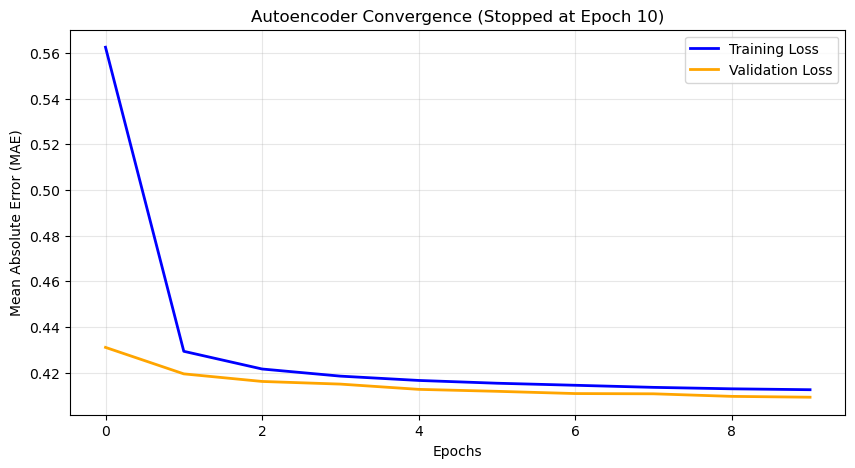

In [ ]:
# --- 7. LSTM AUTOENCODER ---
model = models.Sequential([
    layers.Input(shape=(WINDOW_SIZE, len(feature_cols))),
    layers.LSTM(32, activation='relu', return_sequences=False),
    layers.RepeatVector(WINDOW_SIZE),
    layers.LSTM(32, activation='relu', return_sequences=True),
    layers.TimeDistributed(layers.Dense(len(feature_cols)))
])

model.compile(optimizer='adam', loss='mae')
print(f"Training on {len(X_train_healthy)} healthy sequences...")


In [ ]:

# Define the Early Stopping callback
early_stopper = EarlyStopping(
    monitor='val_loss',          # We want to watch the validation loss
    patience=5,                  # If val_loss doesn't improve for 5 epochs in a row, stop.
    min_delta=0.001,             # Minimum change required to count as an "improvement"
    restore_best_weights=True,   # CRITICAL: Revert to the best epoch's weights when stopping
    verbose=1
)

# 1. Save the training process to a 'history' object
# Notice we added the `callbacks=[early_stopper]` argument here!
history = model.fit(
    X_train_healthy, 
    X_train_healthy, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1, 
    callbacks=[early_stopper], 
    verbose=1
)


In [ ]:

# 2. Plot the Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)

# Get the actual number of epochs it ran for before stopping
actual_epochs = len(history.history['loss'])
plt.title(f'Autoencoder Convergence (Stopped at Epoch {actual_epochs})')

plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show(block=False)

In [ ]:
# --- 8. DATA-DRIVEN THRESHOLD CALCULATION ---
# Get reconstruction error for all training data
train_predictions = model.predict(X_train_full)
train_mae = np.mean(np.abs(train_predictions - X_train_full), axis=(1, 2))

# The threshold is the 99th percentile of error while the engine is STILL HEALTHY
healthy_mae = train_mae[healthy_idx]
smart_threshold = np.percentile(healthy_mae, 87.5 )
print(f"Data-Driven Failure Threshold: {smart_threshold:.4f}")


1525/1525 [==============================] - 23s 15ms/step
Data-Driven Failure Threshold: 0.4475


7/7 [==============================] - 0s 17ms/step


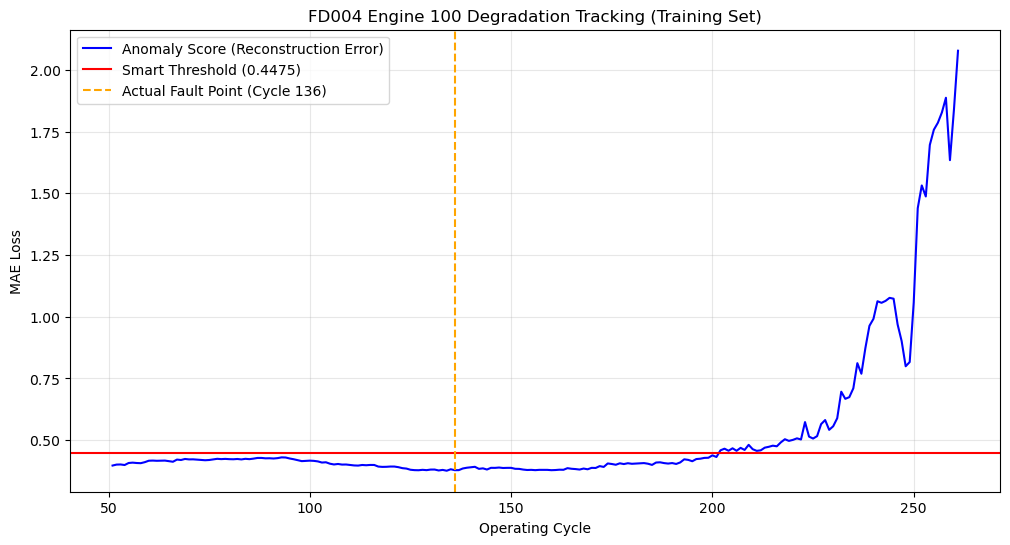

In [ ]:
# --- 9. VISUALIZATION (UNIT 100) ---
unit_id = 100
unit_mask = df['id'] == unit_id
X_unit, cycles_unit, ruls_unit = gen_sequences_and_labels(df[unit_mask], WINDOW_SIZE)

unit_preds = model.predict(X_unit)
unit_mae = np.mean(np.abs(unit_preds - X_unit), axis=(1, 2))

# Find the exact cycle where RUL hits our 125 threshold
fault_cycle = cycles_unit[ruls_unit <= HEALTHY_RUL_THRESHOLD][0] if any(ruls_unit <= HEALTHY_RUL_THRESHOLD) else cycles_unit[-1]


In [ ]:

plt.figure(figsize=(12, 6))
plt.plot(cycles_unit, unit_mae, label='Anomaly Score (Reconstruction Error)', color='blue')
plt.axhline(y=smart_threshold, color='red', linestyle='-', label=f'Smart Threshold ({smart_threshold:.4f})')
plt.axvline(x=fault_cycle, color='orange', linestyle='--', label=f'Actual Fault Point (Cycle {fault_cycle})')

plt.title(f'FD004 Engine {unit_id} Degradation Tracking (Training Set)')
plt.xlabel('Operating Cycle')
plt.ylabel('MAE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show(block=False) 


In [ ]:
# --- 10. SPEARMAN CORRELATION & RUL EVALUATION ---
print("\n--- Starting Test Set Evaluation (Peak Anomaly vs. Final RUL) ---")

# (Keep your existing RUL loading and eval_df preparation)
true_rul_file = f"{path}/RUL_FD004.txt"
true_rul_df = pd.read_csv(true_rul_file, header=None, names=['True_RUL'])
true_rul_df['id'] = true_rul_df.index + 1

test_max_cycles = df_test.groupby('id')['cycle'].max().reset_index()
test_max_cycles.columns = ['id', 'last_test_cycle']

eval_df = test_max_cycles.merge(true_rul_df, on='id')

# We will store one value per engine
engine_max_maes = []
engine_final_ruls = []



--- Starting Test Set Evaluation (Peak Anomaly vs. Final RUL) ---
Extracting peak MAE and Final RUL for each engine...


In [ ]:
print("Extracting peak MAE and Final RUL for each engine...")
for u_id in eval_df['id']:
    unit_mask = df_test['id'] == u_id
    unit_data = df_test[unit_mask]
    
    if len(unit_data) >= WINDOW_SIZE:
        X_test_unit, _, _ = gen_sequences_and_labels(unit_data, WINDOW_SIZE)
        
        # Predict and calculate MAE for the engine sequence
        unit_test_preds = model.predict(X_test_unit, verbose=0)
        unit_test_mae = np.mean(np.abs(unit_test_preds - X_test_unit), axis=(1, 2))
        
        # 1. Capture the PEAK anomaly score for this engine
        engine_max_maes.append(np.max(unit_test_mae))
        
        # 2. Capture the ground truth RUL at the end of the test data
        final_rul = eval_df.loc[eval_df['id'] == u_id, 'True_RUL'].values[0]
        engine_final_ruls.append(final_rul)

In [47]:
# --- 11. CALCULATE STATISTICS ---
# We expect a NEGATIVE correlation: 
# Low RUL (near failure) should have a High Max MAE (high anomaly).
corr, p_value = spearmanr(engine_final_ruls, engine_max_maes)

print(f"\n--- ENGINE-LEVEL EVALUATION METRICS ---")
print(f"Total Engines Evaluated: {len(engine_max_maes)}")
print(f"Spearman Rank Correlation: {corr:.4f}")


--- ENGINE-LEVEL EVALUATION METRICS ---
Total Engines Evaluated: 228
Spearman Rank Correlation: -0.6802


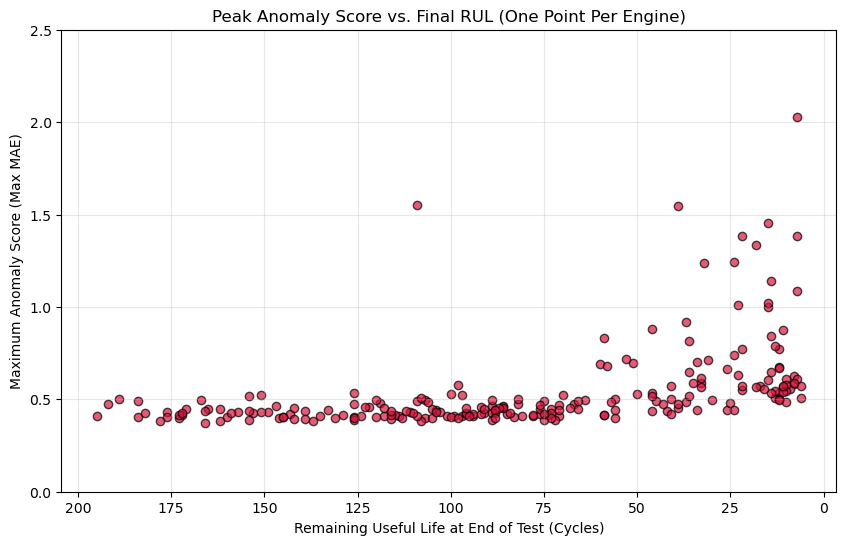

In [48]:
# --- 12. VISUALIZATION: Peak Anomaly vs. Final RUL ---
plt.figure(figsize=(10, 6))
plt.scatter(engine_final_ruls, engine_max_maes, alpha=0.7, color='crimson', edgecolors='k')

# Invert X axis so that the timeline moves toward 0 (Failure)
plt.gca().invert_xaxis()
plt.title('Peak Anomaly Score vs. Final RUL (One Point Per Engine)')
plt.xlabel('Remaining Useful Life at End of Test (Cycles)')
plt.ylim(0, 2.5)
plt.ylabel('Maximum Anomaly Score (Max MAE)')
plt.grid(True, alpha=0.3)
plt.show()

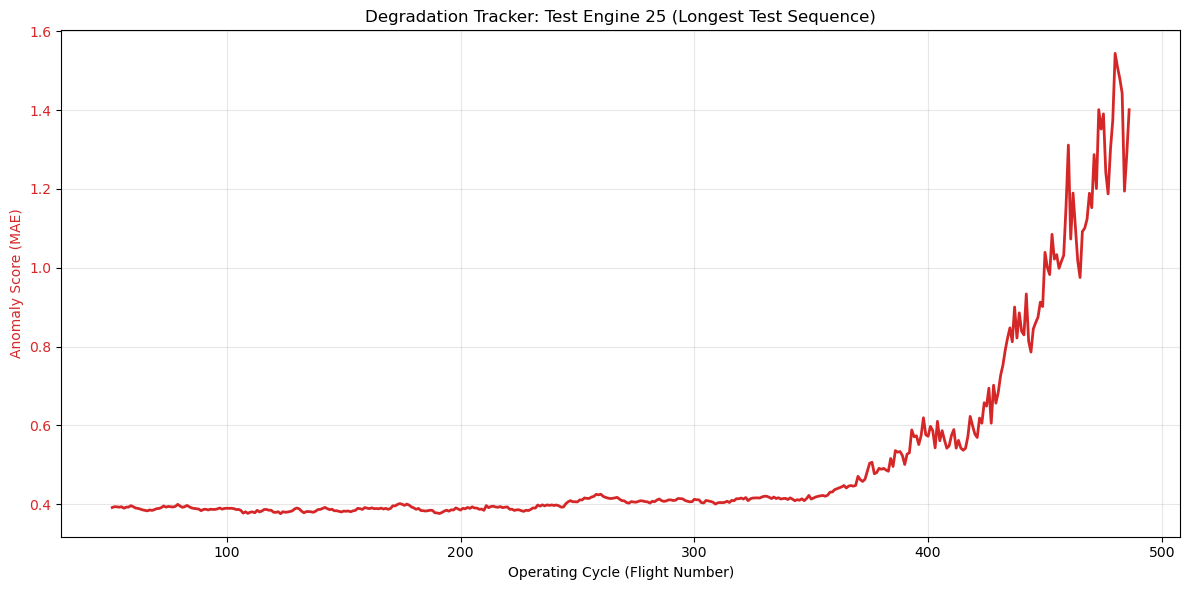

In [49]:
# --- 13. VISUALIZATION 2: Engine Timeline ---
if longest_engine_data is not None:
    cycles, maes, ruls = longest_engine_data
    
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot MAE on left Y-axis
    color = 'tab:red'
    ax1.set_xlabel('Operating Cycle (Flight Number)')
    ax1.set_ylabel('Anomaly Score (MAE)', color=color)
    ax1.plot(cycles, maes, color=color, linewidth=2, label='Model Anomaly Score')
    ax1.tick_params(axis='y', labelcolor=color)

    # Add a title and combine legends
    plt.title(f'Degradation Tracker: Test Engine {int(longest_test_engine)} (Longest Test Sequence)')
    fig.tight_layout()  
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    plt.show() 

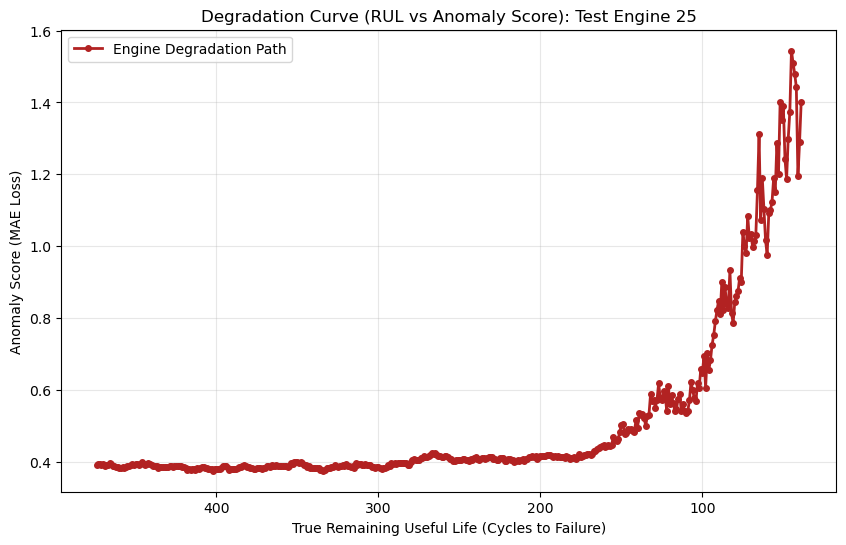

In [50]:
# --- 14. VISUALIZATION 3: Single Engine RUL vs MAE ---
if longest_engine_data is not None:
    cycles, maes, ruls = longest_engine_data
    
    plt.figure(figsize=(10, 6))
    
    # Plot RUL on X-axis and MAE on Y-axis
    # We use a line plot with small markers to see the exact progression
    plt.plot(ruls, maes, color='firebrick', linewidth=2, marker='o', markersize=4, label='Engine Degradation Path')
    
    # Invert X axis so that the timeline moves left-to-right toward 0 (Failure)
    plt.gca().invert_xaxis()
    
    plt.title(f'Degradation Curve (RUL vs Anomaly Score): Test Engine {int(longest_test_engine)}')
    plt.xlabel('True Remaining Useful Life (Cycles to Failure)')
    plt.ylabel('Anomaly Score (MAE Loss)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # We use block=True here because it's the final graph, which keeps the script from instantly closing
    plt.show(block=True)